<a href="https://colab.research.google.com/github/DABMASTER-Brought-me-into-this/ZeroToHeroColabCollection/blob/main/makemore_yay_pt2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
words = open("data.txt").read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [ ]:
# Creating that String to Integer n vice versa
stoi = {char: i+1 for i, char in enumerate(sorted(list(set(''.join(words) + '.'))))}
stoi['.'] = 0
itos = {value: key for key,value in stoi.items()}

In [ ]:
# Defining our starting input & output values
x,y = [], []
block_size = 3 # How much context character wise do we have?

for word in words[:8]:
  context = [0] * block_size # It will be [0, 0, ... ,0] It will be size block_size

  # Going through every character in a word
  for char in word + '.':
    ix = stoi[char]
    x.append(context)
    y.append(ix)
    # print(''.join(itos[c] for c in context), '--->', itos[ix])
    context = context[1:] + [ix]


X = torch.tensor(x)
Y = torch.tensor(y)

In [ ]:
# Our effective weight indexing
C = torch.randn(27, 2)

In [ ]:
emb = C[X]

In [ ]:
# Creating Weights & Biases
W1 = torch.randn((6, 100))
B1 = torch.randn((100))

So now we must take embedding and multiply the weights and biases

Essentially we wanna do this: emb @ W1 + B1

However this will fail bcuz emb is (53, 3, 2) * (6, 100) + (100)

There is an size mismatch



---



One way to fix this is via .cat & .unbind method

The .cat method will take to tensors at any dimension n slap them together

Ex: [5,4].cat([6,7]) [5,4,6,7]

The .unbind method is the opposite ish

So say you have a 2d array of 5 points with a grad.
Smth like this:

[[0, 0.5], [1, -0.9]] etc.

You can use the .unbind on it n u will get:

[0.5, -0.9]

In [ ]:
# An ineffecient method of fixing size mismatch is:
torch.cat(torch.unbind(emb, 1), 1).shape

# This fits our size perfectly but it is super wasteful in terms of operation

torch.Size([53, 6])

In [ ]:
# Tensors store all their data in a flattened array ish
emb.storage() # might not be completely true but here is the visualization

In [ ]:
# You can easily manipulate the dimensions with the .view()
emb.view(53, 6) # Now it fits perfectly but it is more effecient

In [ ]:
# Using this method let's calc the forward pass w/ less hard coding
# Hidden Layer
non = 100 # Number of Neurons
W1 = torch.randn((block_size * 2, non))
B1 = torch.randn((non))
h = emb.view(-1, 6) @ W1 + B1
h = torch.tanh(h)

torch.Size([53, 100])

In [ ]:
# Softmax Layer
W2 = torch.randn(non, 27) # Since there r 27 chars we use 27
B2 = torch.randn(27) # don't understand the dimensions chosen
logits = h @ W2 + B2
counts = logits.exp()
prob = counts / counts.sum(1, keepdim=True) # Don't understand this
prob[0].sum()

tensor(1.0000)

In [ ]:
# Now Calc the loss
loss = -prob[torch.arange(emb.shape[0]), Y].log().mean()

tensor(14.0059)

In [ ]:
# Trying to Train the Neural Network by meself?!
non = 100
W1 = torch.randn((block_size * 2, non), requires_grad=True)
B1 = torch.randn((non), requires_grad=True)
W2 = torch.randn(non, 27, requires_grad=True) # Since there r 27 chars we use 27
B2 = torch.randn(27, requires_grad=True)
for k in range(20):
  ## Forward Pass
  # Hidden Layer 1
  h = emb.view(-1, 6) @ W1 + B1
  h = torch.tanh(h)

  # Softmax Layer
  logits = h @ W2 + B2
  counts = logits.exp()
  prob = counts / counts.sum(1, keepdim=True)

  # Loss
  loss = -prob[torch.arange(emb.shape[0]), Y].log().mean()


  ## Backpropagation
  # Resetting Grads
  W1.grad = None
  W2.grad = None
  B1.grad = None
  B2.grad = None

  # Calculating Grads
  loss.backward()

  W1.data -= W1.grad * 0.5
  W2.data -= W2.grad * 0.5
  B1.data -= B1.grad * 0.5
  B2.data -= B2.grad * 0.5

  print(k, loss.item())

0 17.255043029785156
1 11.136397361755371
2 7.830765247344971
3 5.702253818511963
4 4.959405899047852
5 4.612682819366455
6 3.7604856491088867
7 2.980374336242676
8 2.5320727825164795
9 2.3205087184906006
10 2.0993740558624268
11 1.7030593156814575
12 2.1174380779266357
13 1.4230693578720093
14 1.2199920415878296
15 1.0270776748657227
16 1.2608082294464111
17 0.9164546728134155
18 0.9173969030380249
19 0.8170215487480164


In [ ]:
# It turns out that F.cross_entropy == negative log likelihood
# What is the meaning of life?
logits = h @ W2 + B2
counts = logits.exp()
prob = counts / counts.sum(1, keepdim=True)
loss = -prob[torch.arange(emb.shape[0]), Y].log().mean()
print(loss.item())
loss = F.cross_entropy(logits, Y)
print(loss.item())

0.7115370631217957
0.7115371227264404


### Why to use `F.cross_entropy` over our bootlegged method


Reason #1:

No new intermediate memory wasted. Each variable we created counts & prob need a new memory space. Cross Entropy does not require any new memory
<br></br>
Reason #2:

It calculates the gradient much more effeciently. Think about Tanh. Tanh is:

$$\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}$$

Doing the derivative of each exponent is time consuming and wasteful of computer resources. The derivative of tanh simplifies quite a bit into:

$$\frac{d}{dx}\tanh(x) = 1 - \tanh^2(x)$$


Reason #3:

It is a bit more complicated and will be demonstrated:


In [ ]:
# Let's say these are r ur vars
logits_ex = torch.tensor([-5, 4, 3, 5])
counts_ex = logits_ex.exp()
prob_ex = counts_ex / counts_ex.sum()
print(prob_ex)

# Now let's say you have a rlly big n a rlly negative number
logits_ex = torch.tensor([-1000, 4, 3, 1000])
counts_ex = logits_ex.exp()
prob_ex = counts_ex / counts_ex.sum()
print(prob_ex)

# The prob of 1000 turns into infinity
# Cross entropy deals with this

## Here is how it does it:
# Subtracting/adding does not affect the probabilities
logits_ex = torch.tensor([-5, 4, 3, 5]) + 1
counts_ex = logits_ex.exp()
prob_ex = counts_ex / counts_ex.sum()
print(prob_ex)

# So subtracting the biggest val from it normalizes the probs again
logits_ex = torch.tensor([-1000, 4, 3, 1000]) - 1000
counts_ex = logits_ex.exp()
prob_ex = counts_ex / counts_ex.sum()
print(prob_ex)

tensor([3.0201e-05, 2.4472e-01, 9.0028e-02, 6.6522e-01])
tensor([0., 0., 0., nan])
tensor([3.0201e-05, 2.4472e-01, 9.0028e-02, 6.6522e-01])
tensor([0., 0., 0., 1.])


## Reflection

I unfortunately did the neural net wrong and that is cuz I forgot to factor in that the neural net also adjusts the cords of the letters to each other. Here is the updated w/ the new fix added & all from scratch:

In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import random
%matplotlib inline

In [ ]:
words = open("data.txt").read().splitlines()

In [ ]:
# Our effective cords indexing
C = torch.randn(27, 10)

In [ ]:
# Creating that String to Integer n vice versa
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}

In [ ]:
def build_dataset(words, block_size=3):
  # Defining our starting input & output values
  x,y = [], []

  for word in words:
    context = [0] * block_size # It will be [0, 0, ... ,0] It will be size block_size

    # Going through every character in a word
    for char in word + '.':
      ix = stoi[char]
      x.append(context)
      y.append(ix)
      # print(''.join(itos[c] for c in context), '--->', itos[ix])
      context = context[1:] + [ix]


  X = torch.tensor(x)
  Y = torch.tensor(y)
  return X, Y


n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))
random.shuffle(words)
Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

In [ ]:
emb = C[Xtr]

In [ ]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10 ** lre

In [ ]:
# Trying to Train the Neural Network by meself?!
non = 300
W1 = torch.randn((3 * 10, non), requires_grad=True)
B1 = torch.randn((non), requires_grad=True)
W2 = torch.randn(non, 27, requires_grad=True) # Since there r 27 chars we use 27
B2 = torch.randn(27, requires_grad=True)
C.requires_grad = True
parameters = [C, W1, W2, B1, B2]
lri = []
lossi = []
stepi = []

In [ ]:
for k in range(30000):
  # Mini batching
  ix = torch.randint(0, Xtr.shape[0], (160,))

  ## Forward Pass
  emb = C[Xtr[ix]]
  # Hidden Layer 1
  h = emb.view(-1, 30) @ W1 + B1
  h = torch.tanh(h)

  # Softmax Layer
  logits = h @ W2 + B2

  # Loss
  loss = F.cross_entropy(logits, Ytr[ix])


  ## Backpropagation
  # Resetting Grads
  for p in parameters:
    p.grad = None

  # Calculating Grads
  loss.backward()

  # Updating the data
  for p in parameters:
    p.data += p.grad * -0.1


  # # Adding Stats
  # lri.append(lrs[k])
  lossi.append(loss.item())
  stepi.append(k)



In [ ]:
print(loss.item())

2.301511526107788


In [ ]:
for _ in range(20):

    out = []
    context = [0] * 3 # initialize with all ...
    while True:
        emb = C[torch.tensor([context])] # (1, block_size, d)
        h = torch.tanh(emb.view(1, -1) @ W1 + B1)
        logits = h @ W2 + B2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break

    print(''.join(itos[i] for i in out))

annah.
dachjoni.
kellene.
hmer.
chy.
faklyn.
lyka.
bardontonedink.
linnne.
kockhlendireon.
mondondev.
bromarlejtome.
zari.
farmynalynn.
solleb.
mamixahonaszeya.
zrosen.
asshiyah.
saawnnnae.
amiah.


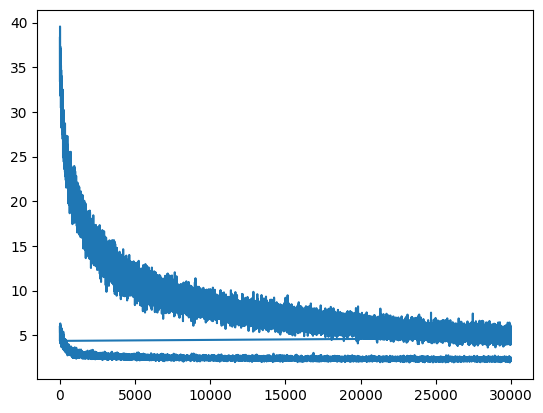

In [ ]:
plt.plot(stepi, lossi)

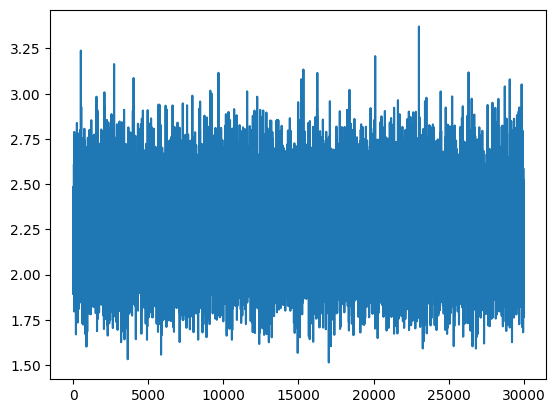

In [ ]:
plt.plot(stepi, lossi)

In [ ]:
# Calc loss for entire set
emb = C[Xdev]
# Hidden Layer 1
h = emb.view(-1, 6) @ W1 + B1
h = torch.tanh(h)
# Softmax Layer
logits = h @ W2 + B2

# Loss
loss = F.cross_entropy(logits, Ydev)
print(loss.item())

2.2670650482177734


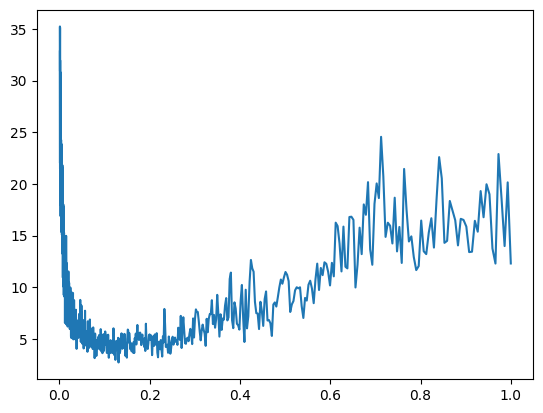

In [ ]:
plt.plot(lri, lossi)

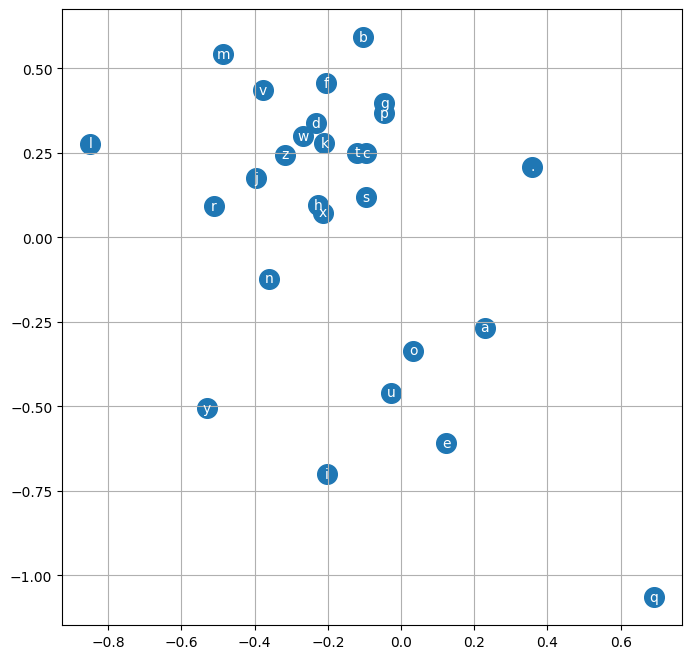

In [ ]:
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
  plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha = 'center', va = 'center', color = 'white')

plt.grid('minor')

In [ ]:
print(loss.item())

1.766886830329895
